https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

## Importing libs

In [230]:
import sys
sys.path.append('..')  # Add parent directory to path
import pandas as pd
from db_setup.query import query_bigquery_table
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Importing Dummyclassifier for baseline model and logistic regression for the actual model
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Libs to plot AUC-ROC curve
from sklearn.metrics import roc_curve, auc

# Lib for pr-AUC curve
from sklearn.metrics import precision_recall_curve, average_precision_score

# MLflow imports
import mlflow

SEED = 42

## MLFlow settings

In [231]:
# Set the experiment name
mlflow.set_tracking_uri("file:///c:/Users/vc/Documents/MLENG_FIAP/mlruns")
mlflow.set_experiment("Telco-Churn-Prediction")

<Experiment: artifact_location='file:///c:/Users/vc/Documents/MLENG_FIAP/mlruns/877441524025029420', creation_time=1775782584433, experiment_id='877441524025029420', last_update_time=1775782584433, lifecycle_stage='active', name='Telco-Churn-Prediction', tags={}, trace_location=None, workspace='default'>

## Initial Visualization of Data

In [232]:
df = query_bigquery_table()
print(df.head())

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\google\auth\_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Iniciando a consulta...
Sucesso! 7043 linhas carregadas.
   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0  9426-SXNHE  Female              0    False       False       2   
1  3806-YAZOV  Female              0    False       False       3   
2  3387-PLKUI  Female              0     True        True      13   
3  8992-CEUEN  Female              0    False       False       1   
4  0620-XEFWH    Male              0     True        True       4   

   PhoneService MultipleLines InternetService       OnlineSecurity  ...  \
0          True            No              No  No internet service  ...   
1          True            No              No  No internet service  ...   
2          True            No              No  No internet service  ...   
3          True            No              No  No internet service  ...   
4          True            No              No  No internet service  ...   

      DeviceProtection          TechSupport          StreamingTV  \
0  No int

In [233]:
df.shape

(7043, 21)

In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   Int64  
 3   Partner           7043 non-null   boolean
 4   Dependents        7043 non-null   boolean
 5   tenure            7043 non-null   Int64  
 6   PhoneService      7043 non-null   boolean
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   boolean


## Checking for empty, nan, null values and zeros

In [235]:
for column in df.columns:
    empty_count = df[df[column] == ""].shape[0]
    empty_space_count = df[df[column] == " "].shape[0]
    null_count = df[df[column].isnull()].shape[0]
    nan_count = df[df[column].isna()].shape[0]
    zero_count = df[df[column] == 0].shape[0]

    if empty_count > 0:
        print(f'Empty values in {column}: {empty_count}')
    if empty_space_count > 0:
        print(f'Empty spaces in {column}: {empty_space_count}')
    if null_count > 0:
        print(f'Null values in {column}: {null_count}')
    if nan_count > 0:
        print(f'Nans in {column}: {nan_count}')
    if zero_count > 0:
        print(f'Zeros in {column}: {zero_count}')

Zeros in SeniorCitizen: 5901
Zeros in Partner: 3641
Zeros in Dependents: 4933
Zeros in tenure: 11
Zeros in PhoneService: 682
Zeros in PaperlessBilling: 2872
Empty spaces in TotalCharges: 11
Zeros in Churn: 5174


In [236]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: Int64

In [237]:
df['Partner'].unique()

<BooleanArray>
[False, True]
Length: 2, dtype: boolean

In [238]:
df['Dependents'].unique()

<BooleanArray>
[False, True]
Length: 2, dtype: boolean

In [239]:
df['tenure'].unique()

<IntegerArray>
[ 2,  3, 13,  1,  4, 10, 20,  6,  9,  7, 12, 18, 25, 22, 27,  8, 36, 35, 11,
  5, 29, 37, 16, 61, 15, 32, 23, 31, 28, 14, 44, 46, 38, 30, 34, 17, 19, 21,
 55, 33, 26, 24, 42, 40, 41, 54, 47, 43, 51, 48, 39, 49, 50, 57, 68, 52, 59,
 64, 56, 58, 53, 60, 45, 71, 67, 65, 66, 62, 63, 69, 70, 72,  0]
Length: 73, dtype: Int64

In [240]:
df['PhoneService'].unique()

<BooleanArray>
[True, False]
Length: 2, dtype: boolean

In [241]:
df['PaperlessBilling'].unique()

<BooleanArray>
[False, True]
Length: 2, dtype: boolean

### Adjusting Total Charges

In [242]:
mean_total_charges = df[df['TotalCharges'] != ' ']['TotalCharges'].astype(float).mean()
print(f'Mean Total Charges: {mean_total_charges}')

Mean Total Charges: 2283.300440841866


In [243]:
median_total_charges = df[df['TotalCharges'] != ' ']['TotalCharges'].astype(float).median()
print(f'Median Total Charges: {median_total_charges}')

Median Total Charges: 1397.475


(array([1525.,  672.,  512.,  458.,  454.,  316.,  276.,  201.,  194.,
         170.,  179.,  159.,  147.,  162.,  145.,  136.,  159.,  117.,
         121.,  146.,  128.,  108.,  102.,  100.,   83.,   74.,   66.,
          64.,   36.,   22.]),
 array([  18.8       ,  307.66666667,  596.53333333,  885.4       ,
        1174.26666667, 1463.13333333, 1752.        , 2040.86666667,
        2329.73333333, 2618.6       , 2907.46666667, 3196.33333333,
        3485.2       , 3774.06666667, 4062.93333333, 4351.8       ,
        4640.66666667, 4929.53333333, 5218.4       , 5507.26666667,
        5796.13333333, 6085.        , 6373.86666667, 6662.73333333,
        6951.6       , 7240.46666667, 7529.33333333, 7818.2       ,
        8107.06666667, 8395.93333333, 8684.8       ]),
 <BarContainer object of 30 artists>)

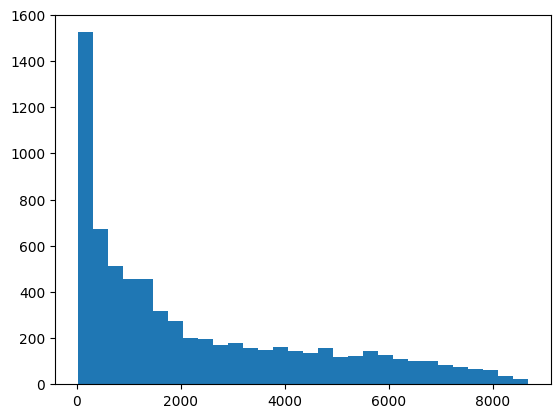

In [244]:
# Histogram of TotalCharges
plt.hist(df[df['TotalCharges'] != ' ']['TotalCharges'].astype(float), bins=30)

In [245]:
df = df[df['TotalCharges'] != ' ']

In [246]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

## Target variable distribution

In [247]:
df['Churn'].value_counts()

Churn
False    5163
True     1869
Name: count, dtype: Int64

## Checking feature distribution

In [248]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [249]:
df['TotalCharges'].astype(float).describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

Text(0.5, 1.0, 'Distribution of Monthly Charges')

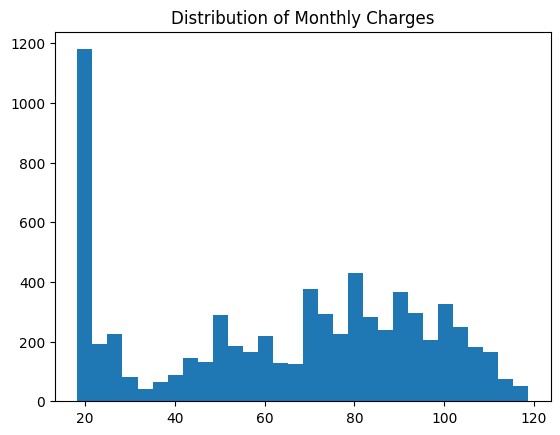

In [250]:
# Ploting a histogram of the MonthlyCharges column
plt.hist(df['MonthlyCharges'], bins=30)
plt.title('Distribution of Monthly Charges')

In [251]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [252]:
df['PaperlessBilling'].value_counts()

PaperlessBilling
True     4168
False    2864
Name: count, dtype: Int64

In [253]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [254]:
df['StreamingMovies'].value_counts()

StreamingMovies
No                     2781
Yes                    2731
No internet service    1520
Name: count, dtype: int64

In [255]:
df['StreamingTV'].value_counts()

StreamingTV
No                     2809
Yes                    2703
No internet service    1520
Name: count, dtype: int64

In [256]:
df['TechSupport'].value_counts()

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

In [257]:
df['DeviceProtection'].value_counts()

DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

In [258]:
df['OnlineBackup'].value_counts()

OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

In [259]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

In [260]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [261]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

In [262]:
df['PhoneService'].value_counts()

PhoneService
True     6352
False     680
Name: count, dtype: Int64

In [263]:
df['Dependents'].value_counts()

Dependents
False    4933
True     2099
Name: count, dtype: Int64

In [264]:
df['Partner'].value_counts()

Partner
False    3639
True     3393
Name: count, dtype: Int64

In [265]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: Int64

In [266]:
df['gender'].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Tenure')

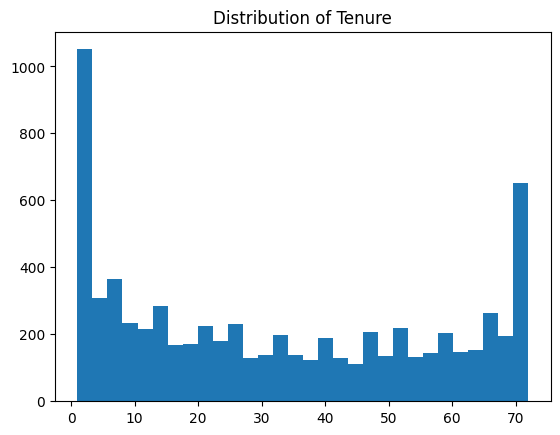

In [267]:
# Ploting a histogram of the tenure column
plt.hist(df['tenure'], bins=30)
plt.title('Distribution of Tenure')

## Onehotencoding the categorical variables

In [268]:
df.set_index('customerID', inplace=True)

In [269]:
# Check which columns are object type
object_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Object type columns:")
print(object_columns)

# One-hot encoding the categorical variables
df_encoded = pd.get_dummies(df, columns=object_columns, drop_first=True)

print(f"\nOriginal shape: {df.shape}")
print(f"After one-hot encoding: {df_encoded.shape}")
print(f"\nNew columns: {df_encoded.columns.tolist()}")

Object type columns:
['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Original shape: (7032, 20)
After one-hot encoding: (7032, 31)

New columns: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', '

In [270]:
## Spliting the data into features and target variable
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

## Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

## Training baseline models

In [271]:
def train_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    # Start MLflow run
    mlflow.start_run()
    
    # Log model parameters
    params = model.get_params()
    for param_name, param_value in params.items():
        mlflow.log_param(param_name, param_value)
    
    # Train model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    
    # AUC-ROC
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    mlflow.log_metric("roc_auc", roc_auc)
    
    # PR-AUC
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    mlflow.log_metric("pr_auc", pr_auc)
    
    # Log model
    mlflow.sklearn.log_model(model, name=model_name)
    # End run
    mlflow.end_run()
    # Print results
    print(f"{model.__class__.__name__} Performance:")
    print(f'Accuracy: {accuracy:.4f}')
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(classification_report(y_test, y_pred))
    
    

In [272]:
# Training a Dummy Classifier as a baseline model
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=SEED)

train_model(dummy_clf, X_train, y_train, X_test, y_test, model_name="Dummy Classifier")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2026/04/09 22:00:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DummyClassifier Performance:
Accuracy: 0.7342
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC-AUC: 0.5000
PR-AUC: 0.2658
              precision    recall  f1-score   support

         0.0       0.73      1.00      0.85      1033
         1.0       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:156

In [273]:
## Training a Logistic Regression model
logreg_clf = LogisticRegression(max_iter=1000, random_state=SEED)

train_model(logreg_clf, X_train, y_train, X_test, y_test, model_name="Logistic Regression")


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/04/09 22:00:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persisten

LogisticRegression Performance:
Accuracy: 0.8031
Precision: 0.6540
Recall: 0.5508
F1 Score: 0.5980
ROC-AUC: 0.8405
PR-AUC: 0.6527
              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1033
         1.0       0.65      0.55      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.80      0.80      0.80      1407



In [274]:
## Training a Logistic Regression model and adding class_weight='balanced' to handle class imbalance
logreg_clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')

train_model(logreg_clf, X_train, y_train, X_test, y_test, model_name="Logistic Regression with Class Weight")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/04/09 22:00:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persisten

LogisticRegression Performance:
Accuracy: 0.7427
Precision: 0.5104
Recall: 0.7861
F1 Score: 0.6189
ROC-AUC: 0.8398
PR-AUC: 0.6494
              precision    recall  f1-score   support

         0.0       0.90      0.73      0.81      1033
         1.0       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407



In [ ]:
TODO: read documentations and apply feature engeering techniques to improve the model performance. Also balance the dataset using techniques like SMOTE or undersampling.